In [1]:
!pip install -q kagglehub

import kagglehub

path = kagglehub.dataset_download(
    "rohanahmedsaad/custard-apple-dataset"
)

print(path)

100%|██████████| 1.00G/1.00G [00:11<00:00, 95.4MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/rohanahmedsaad/custard-apple-dataset/versions/1


In [2]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    break

/root/.cache/kagglehub/datasets/rohanahmedsaad/custard-apple-dataset/versions/1


In [3]:
import os

print(os.listdir(path))

['Sugar Apples  Custard Apples (Annona squamosa) Disease Image Dataset']


In [4]:
import os

DATASET = os.path.join(
    path,
    "Sugar Apples  Custard Apples (Annona squamosa) Disease Image Dataset",
    "Custard Apple dataset"
)

print(os.listdir(DATASET))

['Custard Apple dataset']


In [5]:
import os

for root, dirs, files in os.walk(path):
    print(root)

/root/.cache/kagglehub/datasets/rohanahmedsaad/custard-apple-dataset/versions/1
/root/.cache/kagglehub/datasets/rohanahmedsaad/custard-apple-dataset/versions/1/Sugar Apples  Custard Apples (Annona squamosa) Disease Image Dataset
/root/.cache/kagglehub/datasets/rohanahmedsaad/custard-apple-dataset/versions/1/Sugar Apples  Custard Apples (Annona squamosa) Disease Image Dataset/Custard Apple dataset
/root/.cache/kagglehub/datasets/rohanahmedsaad/custard-apple-dataset/versions/1/Sugar Apples  Custard Apples (Annona squamosa) Disease Image Dataset/Custard Apple dataset/Custard Apple dataset
/root/.cache/kagglehub/datasets/rohanahmedsaad/custard-apple-dataset/versions/1/Sugar Apples  Custard Apples (Annona squamosa) Disease Image Dataset/Custard Apple dataset/Custard Apple dataset/Athracnose
/root/.cache/kagglehub/datasets/rohanahmedsaad/custard-apple-dataset/versions/1/Sugar Apples  Custard Apples (Annona squamosa) Disease Image Dataset/Custard Apple dataset/Custard Apple dataset/Leaf spot 

In [6]:
import os

DATASET = os.path.join(
    path,
    "Sugar Apples  Custard Apples (Annona squamosa) Disease Image Dataset",
    "Custard Apple dataset",
    "Custard Apple dataset"
)

In [7]:
import os

print(os.listdir(DATASET))

['Athracnose', 'Leaf spot on fruit', 'Mealy Bug', 'Leaf spot on Leaves', 'Diplodia Rot', 'Blank Canker']


In [8]:
for cls in os.listdir(DATASET):

    cls_path = os.path.join(DATASET, cls)

    if os.path.isdir(cls_path):
        print(cls, ":", len(os.listdir(cls_path)))

Athracnose : 1075
Leaf spot on fruit : 867
Mealy Bug : 1604
Leaf spot on Leaves : 1255
Diplodia Rot : 1645
Blank Canker : 1780


In [9]:
import tensorflow as tf
import os

from tensorflow.keras.preprocessing import image_dataset_from_directory

DATASET = os.path.join(
    path,
    "Sugar Apples  Custard Apples (Annona squamosa) Disease Image Dataset",
    "Custard Apple dataset",
    "Custard Apple dataset"
)

IMG_SIZE = (224,224)
BATCH = 32

train_ds = image_dataset_from_directory(
    DATASET,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

val_ds = image_dataset_from_directory(
    DATASET,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

class_names = train_ds.class_names

print("Classes:")
print(class_names)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

Found 8226 files belonging to 6 classes.
Using 6581 files for training.
Found 8226 files belonging to 6 classes.
Using 1645 files for validation.
Classes:
['Athracnose', 'Blank Canker', 'Diplodia Rot', 'Leaf spot on Leaves', 'Leaf spot on fruit', 'Mealy Bug']


In [10]:
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV3Small

EPOCHS = 30

base_model = MobileNetV3Small(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model = models.Sequential([

    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation="relu"),

    layers.Dropout(0.4),

    layers.Dense(
        len(class_names),
        activation="softmax"
    )

])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

model.save("baseline_custard.keras")

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 71s 237ms/step - accuracy: 0.3737 - loss: 1.5549 - val_accuracy: 0.2073 - val_loss: 1.8189
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 26s 125ms/step - accuracy: 0.4803 - loss: 1.3520 - val_accuracy: 0.2073 - val_loss: 1.8224
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 41s 125ms/step - accuracy: 0.5554 - loss: 1.1823 - val_accuracy: 0.1945 - val_loss: 1.8315
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 41s 125ms/step - accuracy: 0.6312 - loss: 1.0084 - val_accuracy: 0.1945 - val_loss: 1.8283
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 41s 124ms/step - accuracy: 0.6736 - loss: 0.8901 - val_accuracy: 0.1945 - val_loss: 1.8768
Epoch 6/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 26s 125ms/step - accuracy: 0.7180 - loss: 0.7885 - val_accuracy: 0.1945 - val_loss: 1.9453
Epoch 7/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 26s 124ms/step - accuracy: 0.7509 - loss: 0.6901 - val_accuracy: 0.1945 - val_loss: 2.1330
Epoch 8/30
206/206 ━━━━━━━━━━━━━━━

In [11]:
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV3Small

In [12]:
def cbam_block(x, ratio=8):

    ch = int(x.shape[-1])

    avg = layers.GlobalAveragePooling2D()(x)
    maxp = layers.GlobalMaxPooling2D()(x)

    shared_dense1 = layers.Dense(
        ch // ratio,
        activation="relu"
    )

    shared_dense2 = layers.Dense(ch)

    avg = shared_dense2(
        shared_dense1(avg)
    )

    maxp = shared_dense2(
        shared_dense1(maxp)
    )

    ca = layers.Add()([avg,maxp])

    ca = layers.Activation(
        "sigmoid"
    )(ca)

    ca = layers.Reshape(
        (1,1,ch)
    )(ca)

    x = layers.Multiply()([x,ca])

    avg_pool = layers.Lambda(
        lambda z: tf.reduce_mean(
            z,
            axis=-1,
            keepdims=True
        )
    )(x)

    max_pool = layers.Lambda(
        lambda z: tf.reduce_max(
            z,
            axis=-1,
            keepdims=True
        )
    )(x)

    concat = layers.Concatenate(
        axis=-1
    )([avg_pool,max_pool])

    sa = layers.Conv2D(
        1,
        kernel_size=7,
        padding="same",
        activation="sigmoid"
    )(concat)

    x = layers.Multiply()([x,sa])

    return x

In [13]:
base = MobileNetV3Small(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base.trainable = True

for layer in base.layers[:-30]:
    layer.trainable = False

inputs = layers.Input(
    shape=(224,224,3)
)

x = layers.Rescaling(
    1./255
)(inputs)

x = base(
    x,
    training=False
)

x = cbam_block(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    256,
    activation="relu"
)(x)

x = layers.Dropout(
    0.4
)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

heca_model = Model(
    inputs,
    outputs
)

heca_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = heca_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

heca_model.save(
    "heca_custard.keras"
)

Epoch 1/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 62s 206ms/step - accuracy: 0.3323 - loss: 1.6138 - val_accuracy: 0.2182 - val_loss: 1.7960
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 26s 124ms/step - accuracy: 0.4571 - loss: 1.3893 - val_accuracy: 0.1617 - val_loss: 1.7947
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 26s 126ms/step - accuracy: 0.5312 - loss: 1.2327 - val_accuracy: 0.2134 - val_loss: 1.7950
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 46s 148ms/step - accuracy: 0.5996 - loss: 1.0643 - val_accuracy: 0.2134 - val_loss: 1.8072
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 26s 127ms/step - accuracy: 0.6469 - loss: 0.9624 - val_accuracy: 0.2134 - val_loss: 1.8802
Epoch 6/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 26s 124ms/step - accuracy: 0.6955 - loss: 0.8305 - val_accuracy: 0.2134 - val_loss: 2.2373
Epoch 7/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 41s 125ms/step - accuracy: 0.7332 - loss: 0.7410 - val_accuracy: 0.2134 - val_loss: 2.9672
Epoch 8/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 26s 127ms/step - accuracy: 0.7675 - loss: 0

In [14]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 186ms/step


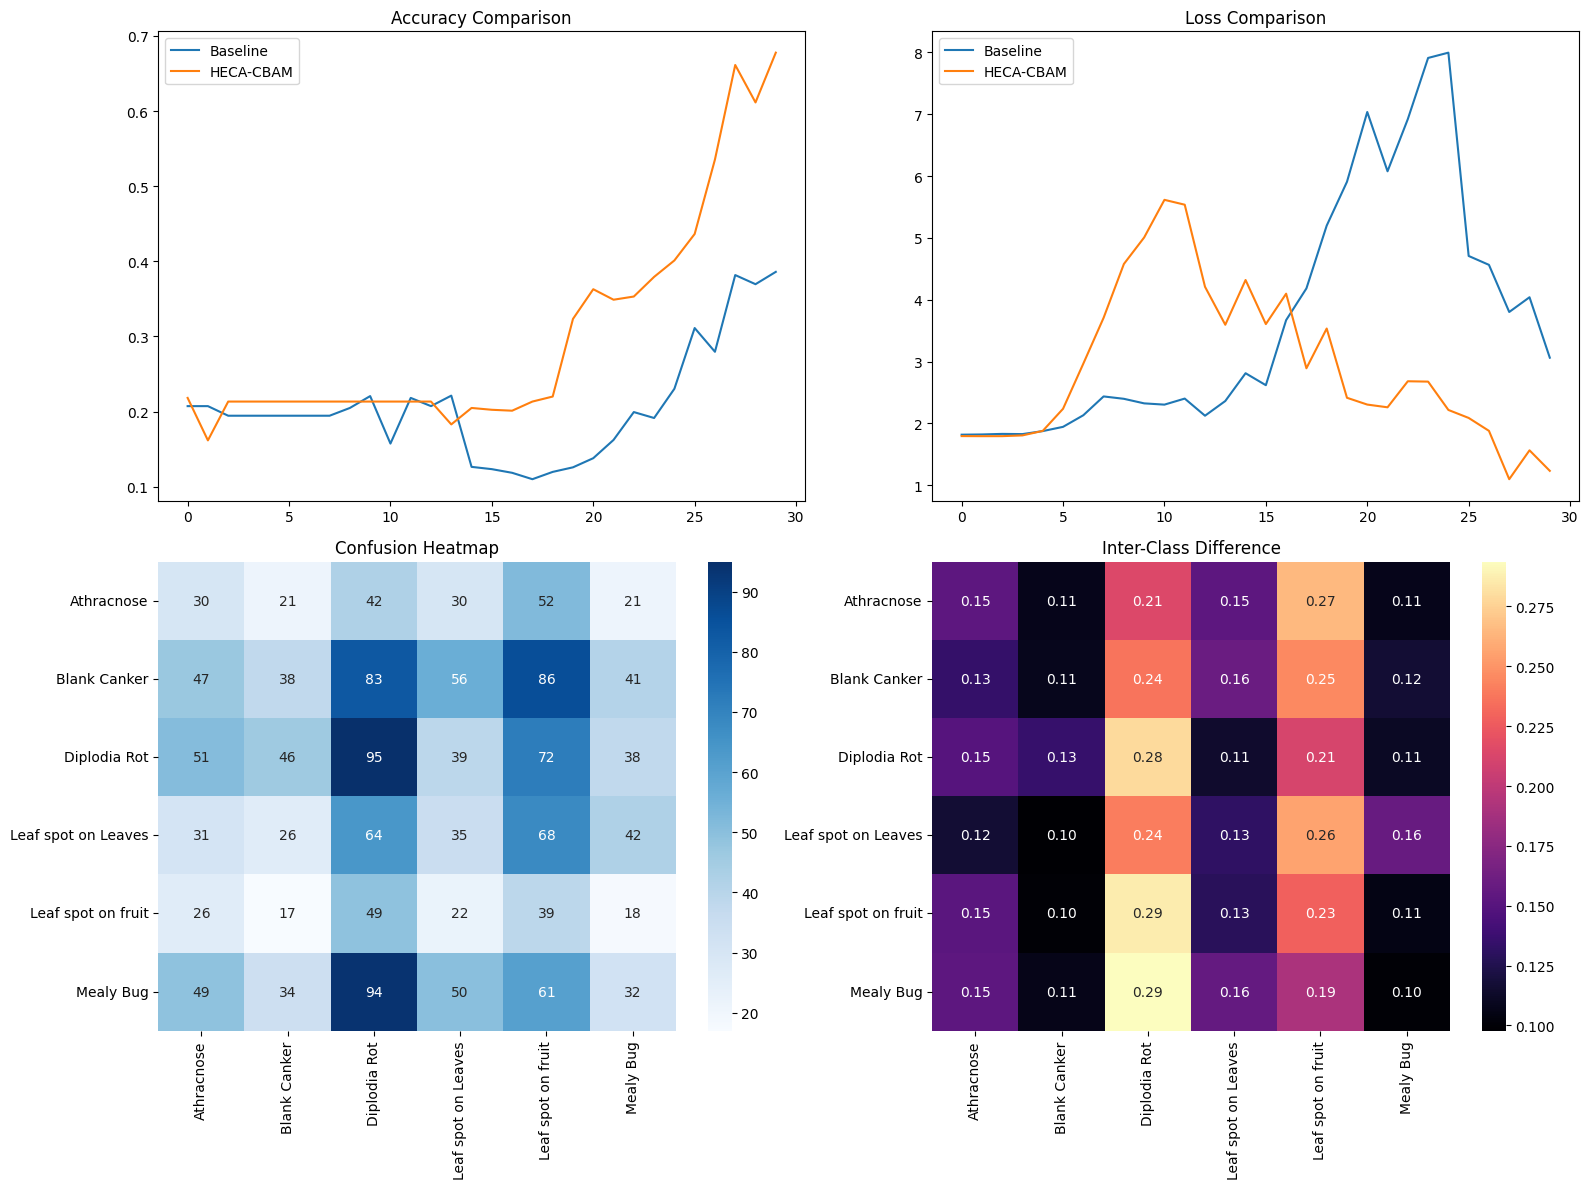

In [15]:
y_true = np.concatenate(
    [y.numpy() for x,y in val_ds],
    axis=0
)

y_pred = np.argmax(
    heca_model.predict(val_ds),
    axis=1
)

cm = confusion_matrix(
    y_true,
    y_pred
)

cm_norm = (
    cm.astype(float)
    /
    cm.sum(axis=1,keepdims=True)
)

cm_norm = np.nan_to_num(
    cm_norm
)

plt.figure(figsize=(16,12))

# Accuracy

plt.subplot(2,2,1)

plt.plot(
    history.history["val_accuracy"],
    label="Baseline"
)

plt.plot(
    history2.history["val_accuracy"],
    label="HECA-CBAM"
)

plt.title("Accuracy Comparison")
plt.legend()

# Loss

plt.subplot(2,2,2)

plt.plot(
    history.history["val_loss"],
    label="Baseline"
)

plt.plot(
    history2.history["val_loss"],
    label="HECA-CBAM"
)

plt.title("Loss Comparison")
plt.legend()

# Heatmap

plt.subplot(2,2,3)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Confusion Heatmap"
)

# Inter-class

plt.subplot(2,2,4)

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="magma",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Inter-Class Difference"
)

plt.tight_layout()
plt.show()